Task 2: Multiple Linear Regression 
● Use the same dataset or load another dataset with at least 4 numeric features. 
● Predict the target variable using multiple independent variables. 
● Evaluate the model using: 
    ○ R-squared 
    ○ Mean Squared Error (MSE) 
    ○ Root Mean Squared Error (RMSE) 
● Display the coefficients of each feature. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.datasets import fetch_california_housing

In [3]:
df = pd.read_csv('housing.csv')
print(df.info())
print(df.columns)# to View all column names

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


In [10]:
features = ['total_rooms', 'housing_median_age', 'total_bedrooms']  
target = 'median_house_value' 

df = df[features + [target]].dropna()

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#training Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

#Predict on test set
y_pred = model.predict(X_test)

#Evaluating the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nModel Evaluation Metrics:")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Step 11: Display the coefficients
print("\nDisplay Feature Coefficients:")
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef:.4f}")

print(f"Intercept: {model.intercept_:.4f}")


Model Evaluation Metrics:
R-squared (R²): 0.0883
Mean Squared Error (MSE): 12467853084.6363
Root Mean Squared Error (RMSE): 111659.5409

Display Feature Coefficients:
total_rooms: 39.0947
housing_median_age: 1697.9528
total_bedrooms: -156.8784
Intercept: 139479.2837


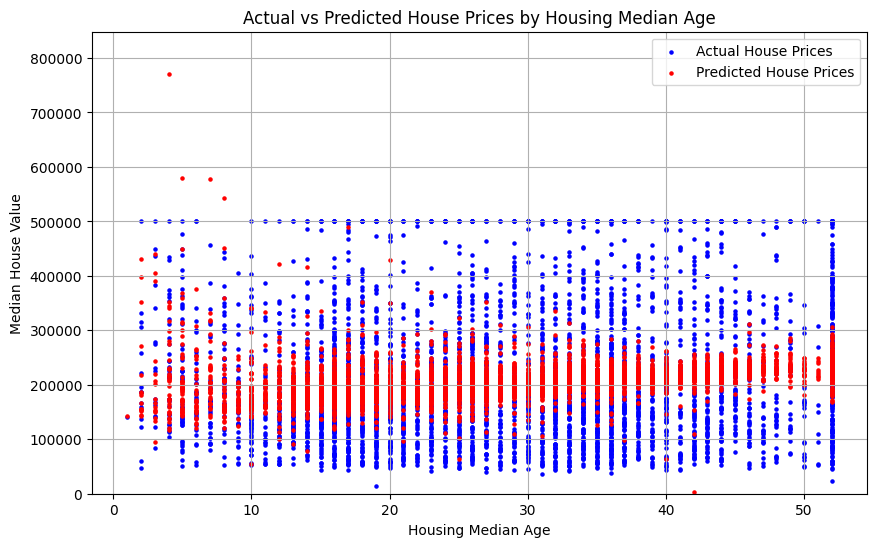

In [16]:
age_index = features.index('housing_median_age')

# Convert X_test to NumPy array for indexing
X_test_array = X_test.to_numpy()

# Extract the housing_median_age values
housing_age = X_test_array[:, age_index]

# Creating scatter plot according to housing median age
plt.figure(figsize=(10, 6))
plt.scatter(housing_age, y_test, color='blue', s=5, label='Actual House Prices')
plt.scatter(housing_age, y_pred, color='red', s=5, label='Predicted House Prices')
plt.xlabel('Housing Median Age')
plt.ylabel('Median House Value')
plt.title('Actual vs Predicted House Prices by Housing Median Age')
plt.grid(True)
plt.legend()
plt.ylim(0, max(y_test.max(), y_pred.max()) * 1.1)
plt.show()